[INFO] Memuat Dataset Benchmark STEAD 10k: STEAD_10k_3C_20260726_173059.json


2026-07-26 18:47:06,705 - [INFO]: Memuat model deep learning MCU-Quake 1D...


[INFO] Total trace yang dimuat: 10000


2026-07-26 18:47:06.741912: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-07-26 18:47:06.741933: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-07-26 18:47:06.741942: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-07-26 18:47:06.741967: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-26 18:47:06.741982: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


2026-07-26 18:47:06,987 - [WARNING]: No training configuration found in save file, so the model was *not* compiled. Compile it manually.
2026-07-26 18:47:06,988 - [INFO]: Memuat data embedding referensi UUSS untuk 3 Komponen...
2026-07-26 18:47:07,307 - [INFO]: Membangun model probabilitas spasial (KDE 3D) berdasarkan UUSS...
2026-07-26 18:47:07,319 - [INFO]: ==================================================
2026-07-26 18:47:07,319 - [INFO]: Memulai iterasi inferensi pada 10000 data STEAD...
2026-07-26 18:47:07,320 - [INFO]: ==================================================
Inferensi STEAD 10k: 100%|██████████| 10000/10000 [03:40<00:00, 45.32it/s]
2026-07-26 18:50:48,003 - [INFO]: ==================================================
2026-07-26 18:50:48,008 - [INFO]: Mengkalkulasi Confusion Matrix dan Metrik Evaluasi...
2026-07-26 18:50:48,080 - [INFO]: Confusion Matrix disimpan di: /Volumes/Extreme SSD/stream_stead/sepuluhribu_stead/benchmark_output_10k/MCU_5-20_STEAD_10K_DOMAIN_202607

Accuracy: [0.4752, 0.4752]
Accuracy (avg.): 0.4752
True positive rate: [0.35313333333333335, 0.8414]
True positive rate (avg.): 0.4752
True negative rate: [0.8414, 0.35313333333333335]
True negative rate (avg.): 0.7193333333333333
Positive predictive value: [0.8697865353037767, 0.30244428468727536]
Positive predictive value (avg.): 0.7279509726496514
Negative predictive value: [0.30244428468727536, 0.8697865353037767]
Negative predictive value (avg.): 0.44427984734140064
False positive rate: [0.1586, 0.6468666666666667]
False positive rate (avg.): 0.2806666666666667
False negative rate: [0.6468666666666667, 0.1586]
False negative rate (avg.): 0.5248
False discovery rate: [0.13021346469622333, 0.6975557153127246]
False discovery rate (avg.): 0.27204902735034864
F1-score: [0.5023233760075866, 0.4449497620306716]
F1-score (avg.): 0.48797997251335784
[DEBUG] Nilai yang akan diplot: [0.4752, 0.4752, 0.7279509726496514, 0.2806666666666667, 0.48797997251335784]


2026-07-26 18:50:48,238 - [INFO]: 
****************************************
2026-07-26 18:50:48,241 - [INFO]:   RINGKASAN PERFORMA - STEAD 10K 3C
2026-07-26 18:50:48,246 - [INFO]: ****************************************
2026-07-26 18:50:48,249 - [INFO]:   Akurasi (Accuracy) : 0.4752
2026-07-26 18:50:48,251 - [INFO]:   Presisi (Precision): 0.7280
2026-07-26 18:50:48,260 - [INFO]:   Sensitivitas (TPR) : 0.4752
2026-07-26 18:50:48,262 - [INFO]:   Skor F1 (F1-Score) : 0.4880
2026-07-26 18:50:48,263 - [INFO]:   Alarm Palsu (FPR)  : 0.2807
2026-07-26 18:50:48,263 - [INFO]: ****************************************
2026-07-26 18:50:48,266 - [INFO]: Pengujian Benchmark Selesai dengan Sukses.


[INFO] Grafik metrik komprehensif tersimpan di: /Volumes/Extreme SSD/stream_stead/sepuluhribu_stead/benchmark_output_10k/MCU_5-20_STEAD_10K_DOMAIN_20260726_184706/STEAD_10K_3C_metrics_bar.jpg


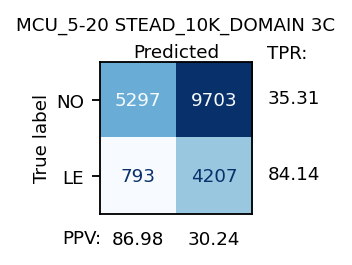

In [1]:
# -*- coding: utf-8 -*-
import os
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tqdm import tqdm
from datetime import datetime
import logging
import matplotlib.pyplot as plt

# Asumsi: Library utils dan dataset Anda sudah ada di direktori yang sama atau PYTHONPATH
from Library import utils, dataset

# ===================================================================
# FUNGSI VISUALISASI METRIK KOMPREHENSIF
# ===================================================================
def plot_comprehensive_metrics(metrics, save_path):
    labels = ['Accuracy', 'Recall', 'Precision', 'FPR', 'F1-Score']
    keys = [
        'Accuracy (avg.)', 
        'True positive rate (avg.)', 
        'Positive predictive value (avg.)', 
        'False positive rate (avg.)', 
        'F1-score (avg.)'
    ]
    values = [metrics.get(k, 0) for k in keys]
    print(f"[DEBUG] Nilai yang akan diplot: {values}") 

    plt.figure(figsize=(12, 6))
    bars = plt.bar(labels, values, color=['#2c3e50', '#3498db', '#e67e22', '#e74c3c', '#27ae60'])
    plt.ylim(0, 1.0)
    plt.ylabel('Score')
    plt.title('Performance Metrics Evaluation (Average) - STEAD 10k Benchmark')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Menambahkan label nilai di atas setiap batang
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom')
        
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()
    print(f"[INFO] Grafik metrik komprehensif tersimpan di: {save_path}")

# ===================================================================
# MAIN EXECUTION
# ===================================================================
if __name__ == "__main__":

    # -------------------------------------------------------------------
    # 1. KONFIGURASI PATH DAN PARAMETER (SESUAIKAN DENGAN WORKSTATION ANDA)
    # -------------------------------------------------------------------
    KEY_DATA_DIR = "/Volumes/Extreme SSD/stream_stead/data_stead/stead_sample_10000"
    KEY_TEST_FILE = 'STEAD_10k_3C_20260726_173059.json' # Ganti dengan nama file JSON hasil ekstraksi Anda yang sesungguhnya
    
    DATA_TAG = "STEAD_10K_DOMAIN"
    MODEL_TAG = "MCU_5-20"
    
    INPUT_WIN = 7  # Jendela waktu dalam detik (standar MCU-Quake)
    SAMPLING_RATE = 100 # 100 Hz
    num_points = int(INPUT_WIN * SAMPLING_RATE) # 700 titik sampel
    
    # Label kelas: 'no' (Noise) = 0, 'le' (Local Earthquake) = 1
    true_labels = ["NO", "LE"]  
    source_to_code = {"no": 0, "le": 1}  

    # Direktori Model dan Embedding Referensi (UUSS)
    BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
    MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
    EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909")

    # -------------------------------------------------------------------
    # 2. PERSIAPAN FILE DAN LOGGER
    # -------------------------------------------------------------------
    print(f"[INFO] Memuat Dataset Benchmark STEAD 10k: {KEY_TEST_FILE}")
    json_path = os.path.join(KEY_DATA_DIR, KEY_TEST_FILE)
    
    # Memuat data uji (pastikan load_json_data menangani exception jika file tidak ada)
    test_data = dataset.load_json_data(json_path)
    keys_list = list(test_data.keys())
    print(f"[INFO] Total trace yang dimuat: {len(keys_list)}")

    # Setup folder output dengan penanda waktu
    SAVE_BASE = '/Volumes/Extreme SSD/stream_stead/sepuluhribu_stead/benchmark_output_10k'
    time_str = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_dir = os.path.join(SAVE_BASE, f"{MODEL_TAG}_{DATA_TAG}_{time_str}")
    os.makedirs(save_dir, exist_ok=True)

    # Konfigurasi sistem logging
    log_file_path = os.path.join(save_dir, "task_log_stead_10k.txt")
    logging.basicConfig(level=logging.INFO,
                        format='%(asctime)s - [%(levelname)s]: %(message)s',
                        handlers=[
                            logging.FileHandler(log_file_path, mode='w'),
                            logging.StreamHandler()
                        ])
    logger = logging.getLogger()

    # -------------------------------------------------------------------
    # 3. MEMUAT MODEL DAN ESTIMASI KDE (KERNEL DENSITY ESTIMATION)
    # -------------------------------------------------------------------
    logger.info("Memuat model deep learning MCU-Quake 1D...")
    embedding_model = keras.models.load_model(filepath=MODEL_PATH)
    
    logger.info("Memuat data embedding referensi UUSS untuk 3 Komponen...")
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embedding_N = dataset.load_embedding_data(EMB_DIR, "Embedding data, N.json")
    embedding_E = dataset.load_embedding_data(EMB_DIR, "Embedding data, E.json")

    logger.info("Membangun model probabilitas spasial (KDE 3D) berdasarkan UUSS...")
    embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E)


    # -------------------------------------------------------------------
    # 4. PROSES INFERENSI (EVALUASI 3-KOMPONEN)
    # -------------------------------------------------------------------
    total_true = []
    total_pred = []
    
    logger.info("="*50)
    logger.info(f"Memulai iterasi inferensi pada {len(keys_list)} data STEAD...")
    logger.info("="*50)

    for i in tqdm(range(len(keys_list)), desc="Inferensi STEAD 10k"):
        record_key = keys_list[i]
        record = test_data[record_key]
        
        # 'le' untuk gempa lokal, 'no' untuk noise
        true_label = record.get("type", "unknown") 
        
        try:
            # Slicing input window (700 sampel), pastikan data sudah ter-detrend dan ternormalisasi
            E_n = np.array(record["E_noise"][:num_points])
            N_n = np.array(record["N_noise"][:num_points])
            Z_n = np.array(record["Z_noise"][:num_points])

            E_s = np.array(record["E"][:num_points])
            N_s = np.array(record["N"][:num_points])
            Z_s = np.array(record["Z"][:num_points])

            # Ekstraksi Latent Codes untuk Noise Window (Jendela Pra-P)
            _in_En = utils.latent_codes_1D(E_n, embedding_model)
            _in_Nn = utils.latent_codes_1D(N_n, embedding_model)
            _in_Zn = utils.latent_codes_1D(Z_n, embedding_model)

            # Ekstraksi Latent Codes untuk Signal Window (Jendela Utama)
            _in_Es = utils.latent_codes_1D(E_s, embedding_model)
            _in_Ns = utils.latent_codes_1D(N_s, embedding_model)
            _in_Zs = utils.latent_codes_1D(Z_s, embedding_model)

            # Inferensi KDE 3C untuk Noise Window
            emb_n = np.array([_in_En, _in_Nn, _in_Zn]).reshape(1, -1)
            p_n, _, _ = utils.infer_3C_PDFs(emb_n, embeddings_3C_PDFs, "Kernel")
            
            # Inferensi KDE 3C untuk Signal Window
            emb_s = np.array([_in_Es, _in_Ns, _in_Zs]).reshape(1, -1)
            p_s, _, _ = utils.infer_3C_PDFs(emb_s, embeddings_3C_PDFs, "Kernel")
            
            # Logika Pelabelan Ground Truth Dinamis
            # Jendela prepick (noise) selalu bernilai 0 (Noise)
            true_n_class = 0 
            # Jendela utama bernilai 1 jika gempa ('le'), dan 0 jika ia memang noise murni ('no')
            true_s_class = 1 if true_label == "le" else 0
            
            # Tambahkan Ground Truth ke list
            total_true.extend([true_n_class, true_s_class]) 
            
            # Tambahkan Prediksi Model (Asumsi p >= 1.0 berarti Gempa)
            total_pred.extend([1 if p_n >= 1.0 else 0, 1 if p_s >= 1.0 else 0])
            
        except Exception as e:
            logger.error(f"Pengecualian (Error) pada trace {record_key}: {e}")
            continue

    # -------------------------------------------------------------------
    # 5. KALKULASI METRIK & PENYIMPANAN VISUALISASI
    # -------------------------------------------------------------------
    logger.info("="*50)
    logger.info("Mengkalkulasi Confusion Matrix dan Metrik Evaluasi...")
    
    # Hitung metrik komprehensif menggunakan utils
    matrix_3C, metrics_3C = utils.calc_confusion_metrics(total_true, total_pred)
    
    # Simpan Gambar Confusion Matrix
    conf_matrix_path = os.path.join(save_dir, "STEAD_10K_3C_confusion.jpg")
    fig_3C = utils.plot_confusion(f"{MODEL_TAG} {DATA_TAG} 3C", true_labels, matrix_3C, metrics_3C)
    fig_3C.savefig(conf_matrix_path, dpi=300)
    logger.info(f"Confusion Matrix disimpan di: {conf_matrix_path}")
    
    # Simpan JSON Metrics
    metrics_json_path = os.path.join(save_dir, "stead_10k_metrics.json")
    dataset.save_json_data(metrics_json_path, metrics_3C)
    logger.info(f"Detail metrik JSON disimpan di: {metrics_json_path}")
    
    # Buat Bar Chart Komprehensif
    bar_chart_path = os.path.join(save_dir, "STEAD_10K_3C_metrics_bar.jpg")
    plot_comprehensive_metrics(metrics_3C, bar_chart_path)

    # Ringkasan di Terminal
    logger.info("\n" + "*"*40)
    logger.info(f"  RINGKASAN PERFORMA - STEAD 10K 3C")
    logger.info("*"*40)
    logger.info(f"  Akurasi (Accuracy) : {metrics_3C.get('Accuracy (avg.)', 0):.4f}")
    logger.info(f"  Presisi (Precision): {metrics_3C.get('Positive predictive value (avg.)', 0):.4f}")
    logger.info(f"  Sensitivitas (TPR) : {metrics_3C.get('True positive rate (avg.)', 0):.4f}")
    logger.info(f"  Skor F1 (F1-Score) : {metrics_3C.get('F1-score (avg.)', 0):.4f}")
    logger.info(f"  Alarm Palsu (FPR)  : {metrics_3C.get('False positive rate (avg.)', 0):.4f}")
    logger.info("*"*40)
    logger.info("Pengujian Benchmark Selesai dengan Sukses.")